# JAX-GCM (JCM) Demo 

<img src="../logo.png" alt="JAX-GCM Logo" width="200"/>

This notebook demonstrates the capabilities of JAX-GCM (JCM), a differentiable general circulation model built using JAX. 

We will showcase how to set up a simple atmospheric simulation, run the model, and visualize the results. Additionally, we will illustrate how to compute gradients with respect to model parameters using JAX's automatic differentiation features.



In [ ]:
import numpy as np
from jcm.model import Model
from jcm.physics.icon.icon_terms import icon_physics
from jcm.physics.icon.parameters import Parameters
from jcm.terrain import TerrainData
from jcm.utils import get_coords

# Create coordinates and terrain for aquaplanet
sigma_boundaries = np.linspace(0, 1, 41)  # 40 layers
coords = get_coords(sigma_boundaries, spectral_truncation=31)
terrain = TerrainData.aquaplanet(coords)

physics = icon_physics()

model = Model(
    coords=coords,
    terrain=terrain,
    physics=physics,
)

save_interval, total_time = 1, 15
predictions = model.run(
    save_interval=save_interval,
    total_time=total_time,
)

In [14]:
# create non-hybrid coords
# from dinosaur.coordinate_systems import CoordinateSystem
# _coords = CoordinateSystem(model.coords.horizontal, model.coords.vertical.to_approx_sigma_coords(40))
pred_ds = predictions.to_xarray(physics)
pred_ds

Skipping single time dimension array: date.tyear with shape (1, 15)
Skipping single time dimension array: date.dt._delta._days with shape (1, 15)
Skipping single time dimension array: date.dt._delta._seconds with shape (1, 15)
Skipping single time dimension array: date.model_year with shape (1, 15)
Skipping single time dimension array: date.model_step with shape (1, 15)
Skipping single time dimension array: date.dt_seconds with shape (1, 15)
Skipping interface-level data: diagnostics.pressure_half with shape (15, 41, 96, 48)
Skipping interface-level data: diagnostics.height_half with shape (15, 41, 96, 48)
Skipping interface-level multi-channel array: radiation.sw_flux_up with shape (15, 41, 96, 48, 10)
Skipping interface-level multi-channel array: radiation.sw_flux_down with shape (15, 41, 96, 48, 10)
Skipping interface-level multi-channel array: radiation.lw_flux_up with shape (15, 41, 96, 48, 10)
Skipping interface-level multi-channel array: radiation.lw_flux_down with shape (15, 41

<xarray.Dataset> Size: 386MB
Dimensions:                                  (time: 15, level: 40, lon: 96,
                                              lat: 48)
Coordinates:
  * lon                                      (lon) float64 768B 0.0 ... 356.2
  * lat                                      (lat) float64 384B -87.16 ... 87.16
  * level                                    (level) float32 160B 0.9875 ... ...
  * time                                     (time) datetime64[ns] 120B 2000-...
Data variables: (12/70)
    diagnostics.layer_thickness              (time, level, lon, lat) float32 11MB ...
    clouds.precip_rain                       (time, lon, lat) float32 276kB ...
    specific_humidity                        (time, level, lon, lat) float32 11MB ...
    clouds.precip_snow                       (time, lon, lat) float32 276kB ...
    vertical_diffusion.monin_obukhov_length  (time, lon, lat) float32 276kB ...
    vertical_diffusion.kh                    (time, level, lon, lat) float32 11MB ...
    ...                                       ...
    radiation.surface_emissivity             (time, lon, lat) float32 276kB ...
    convection.precip_conv                   (time, lon, lat) float32 276kB ...
    clouds.qs                                (time, level, lon, lat) float32 11MB ...
    chemistry.ozone_dry_deposition           (time, lon, lat) float32 276kB ...
    u_wind                                   (time, level, lon, lat) float32 11MB ...
    temperature                              (time, level, lon, lat) float32 11MB ...

## Composable Physics

JCM supports composable physics — you can mix and match parameterizations from different packages,
replace individual schemes, or remove terms entirely. The composable API provides the same
functionality as the prior monolithic IconPhysics orchestrator but with fine-grained control over individual terms.

In [ ]:
from jcm.physics.icon.icon_terms import icon_physics

# Create composable ICON physics with standard ordering
composable = icon_physics()
print("Terms:", [t.name for t in composable.terms])

# Use the NN radiation emulator instead of grey radiation
composable_emulated = icon_physics(radiation_scheme="emulated")

# Remove gravity waves for faster testing
composable_no_gw = icon_physics().remove("gravity_waves")
print("Without gravity waves:", [t.name for t in composable_no_gw.terms])

# Use composable physics in a model (same interface as legacy)
# model = Model(coords=coords, terrain=terrain, physics=composable)

### Mixing SPEEDY and ICON terms

The composable API also works with SPEEDY physics. Both packages' terms are `PhysicsTerm`
subclasses that share the same interface, enabling cross-package composition.

In [ ]:
from jcm.physics.speedy.speedy_terms import speedy_physics

# Create composable SPEEDY physics
speedy = speedy_physics()
print("SPEEDY terms:", [t.name for t in speedy.terms])

# Each term stores its own tunable parameters as flax.nnx.Param,
# enabling per-scheme gradient-based optimization
for term in speedy.terms[:3]:
    print(f"  {term.name} ({term.category})")

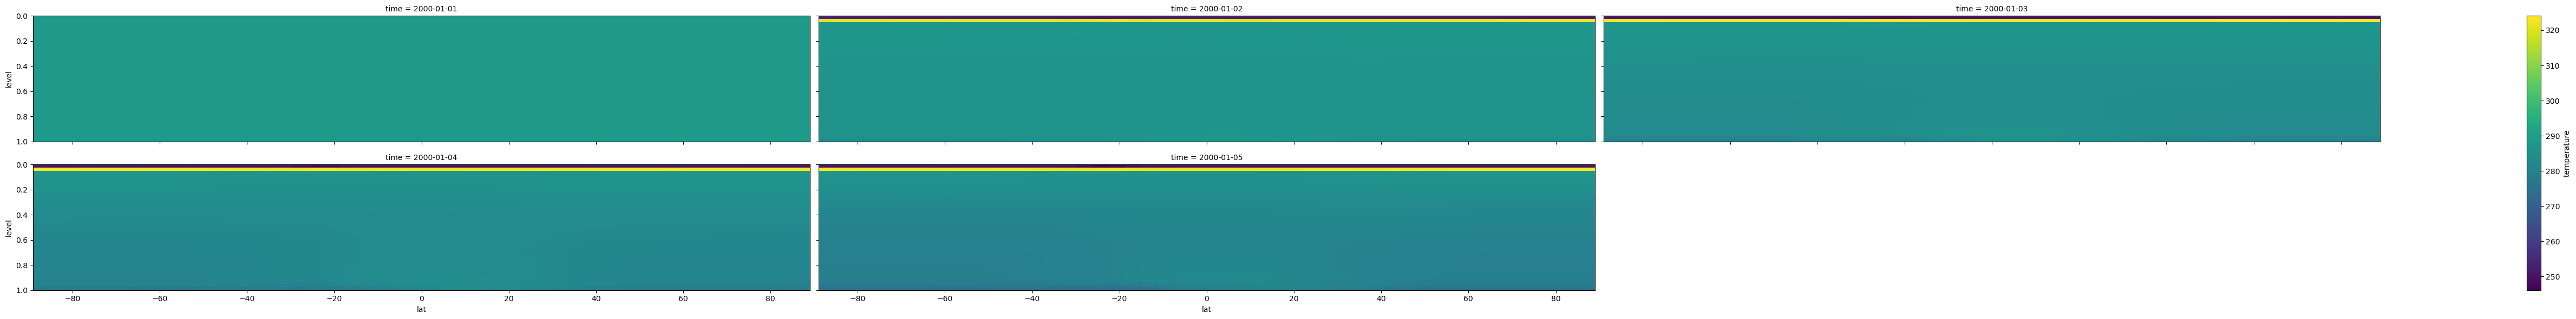

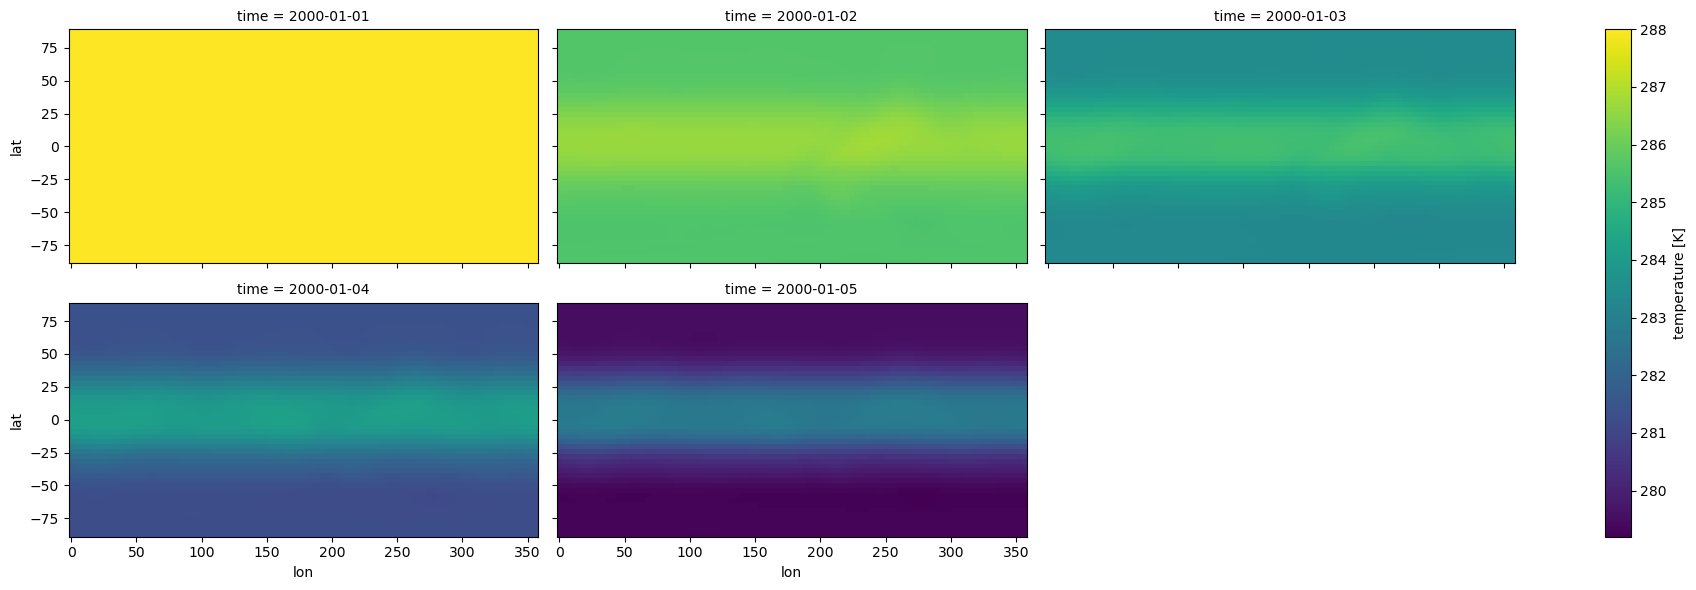

In [10]:
pred_ds['temperature'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
pred_ds['temperature'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

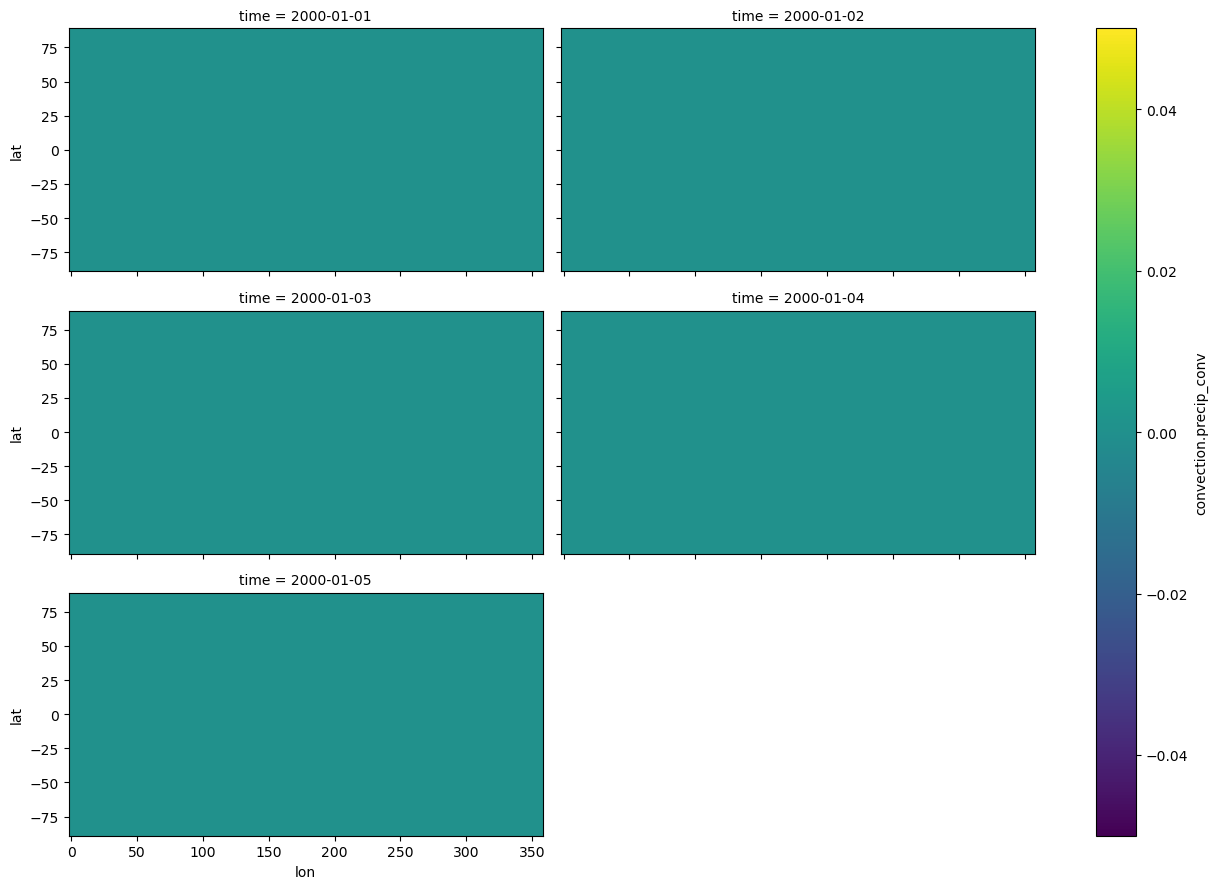

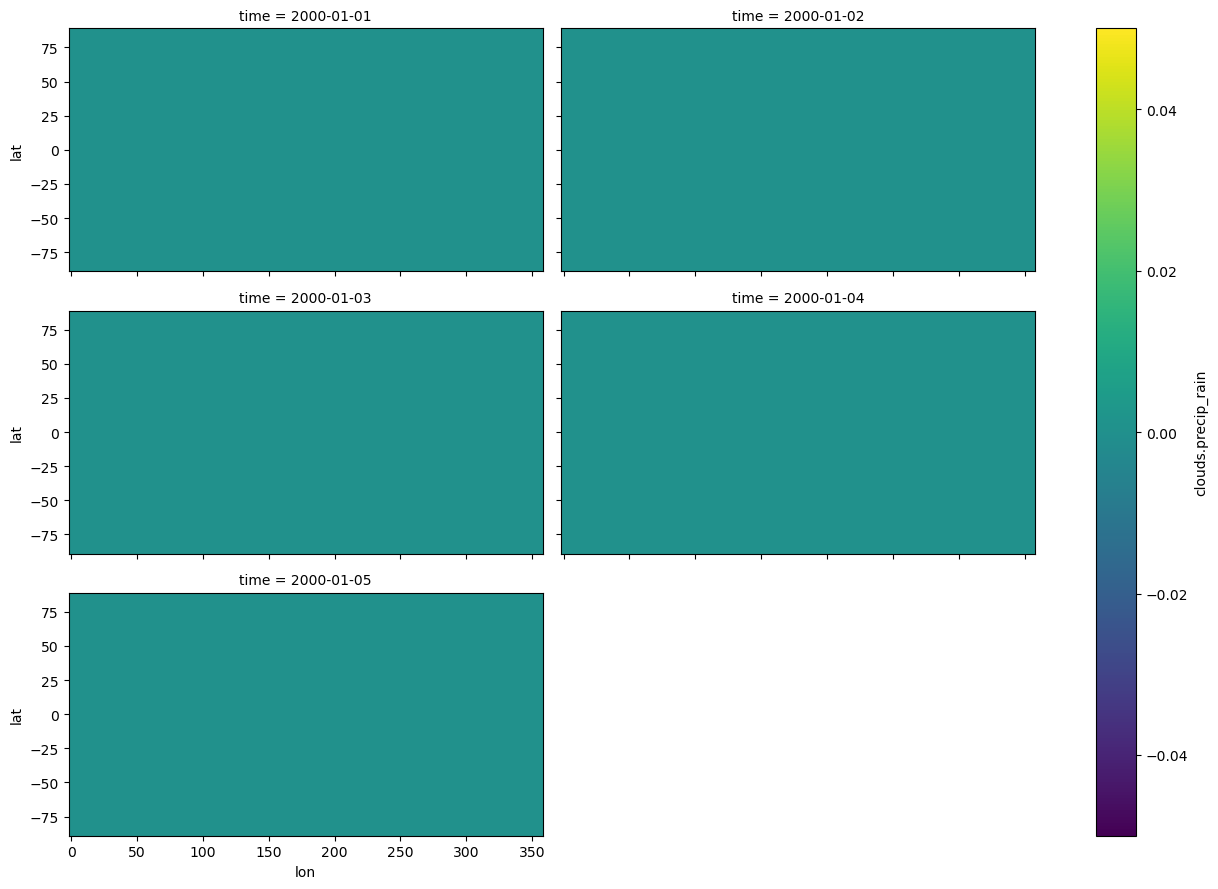

In [12]:
pred_ds['convection.precip_conv'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)
pred_ds['clouds.precip_rain'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)

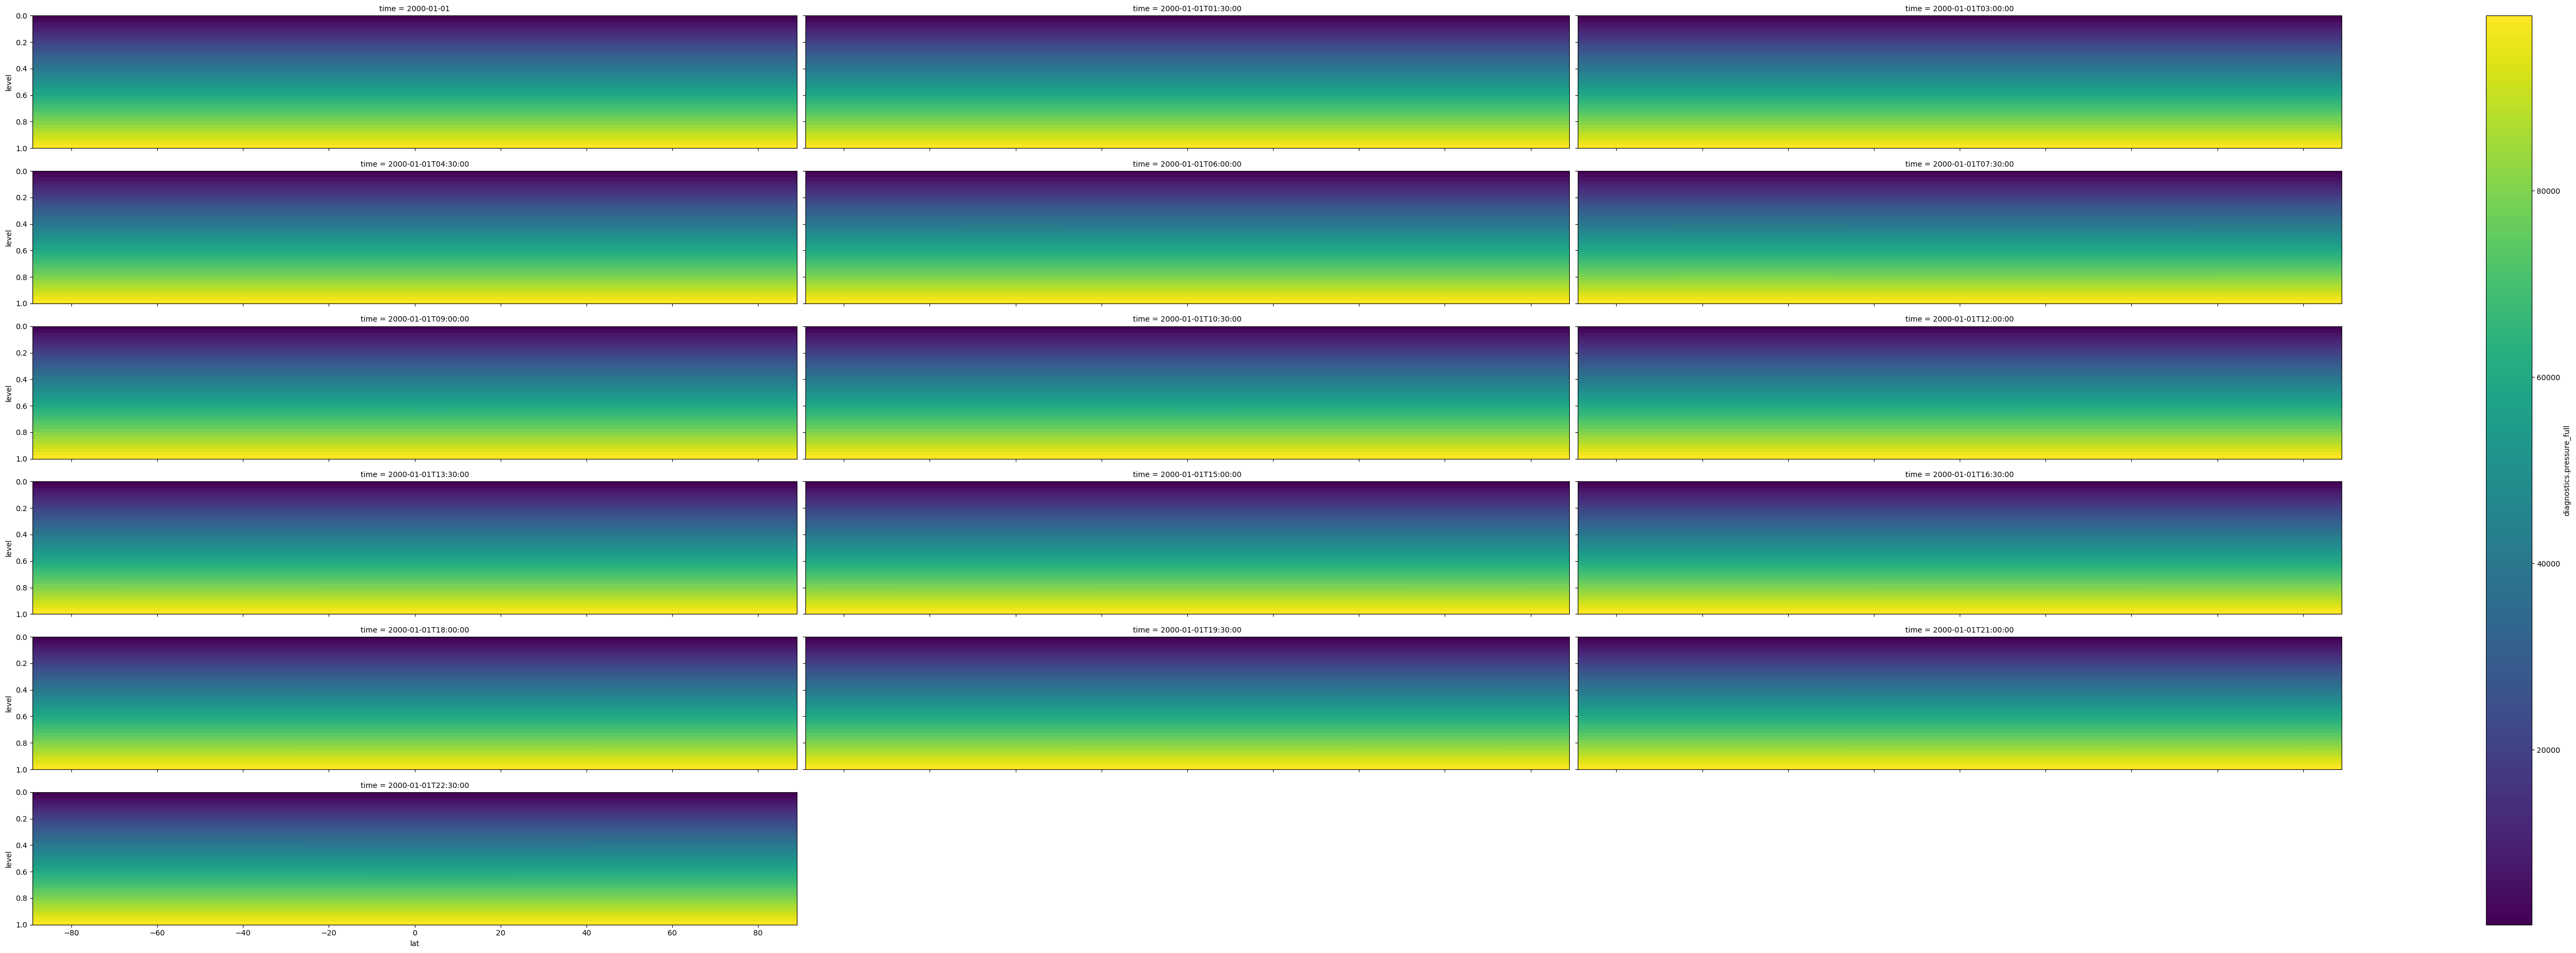

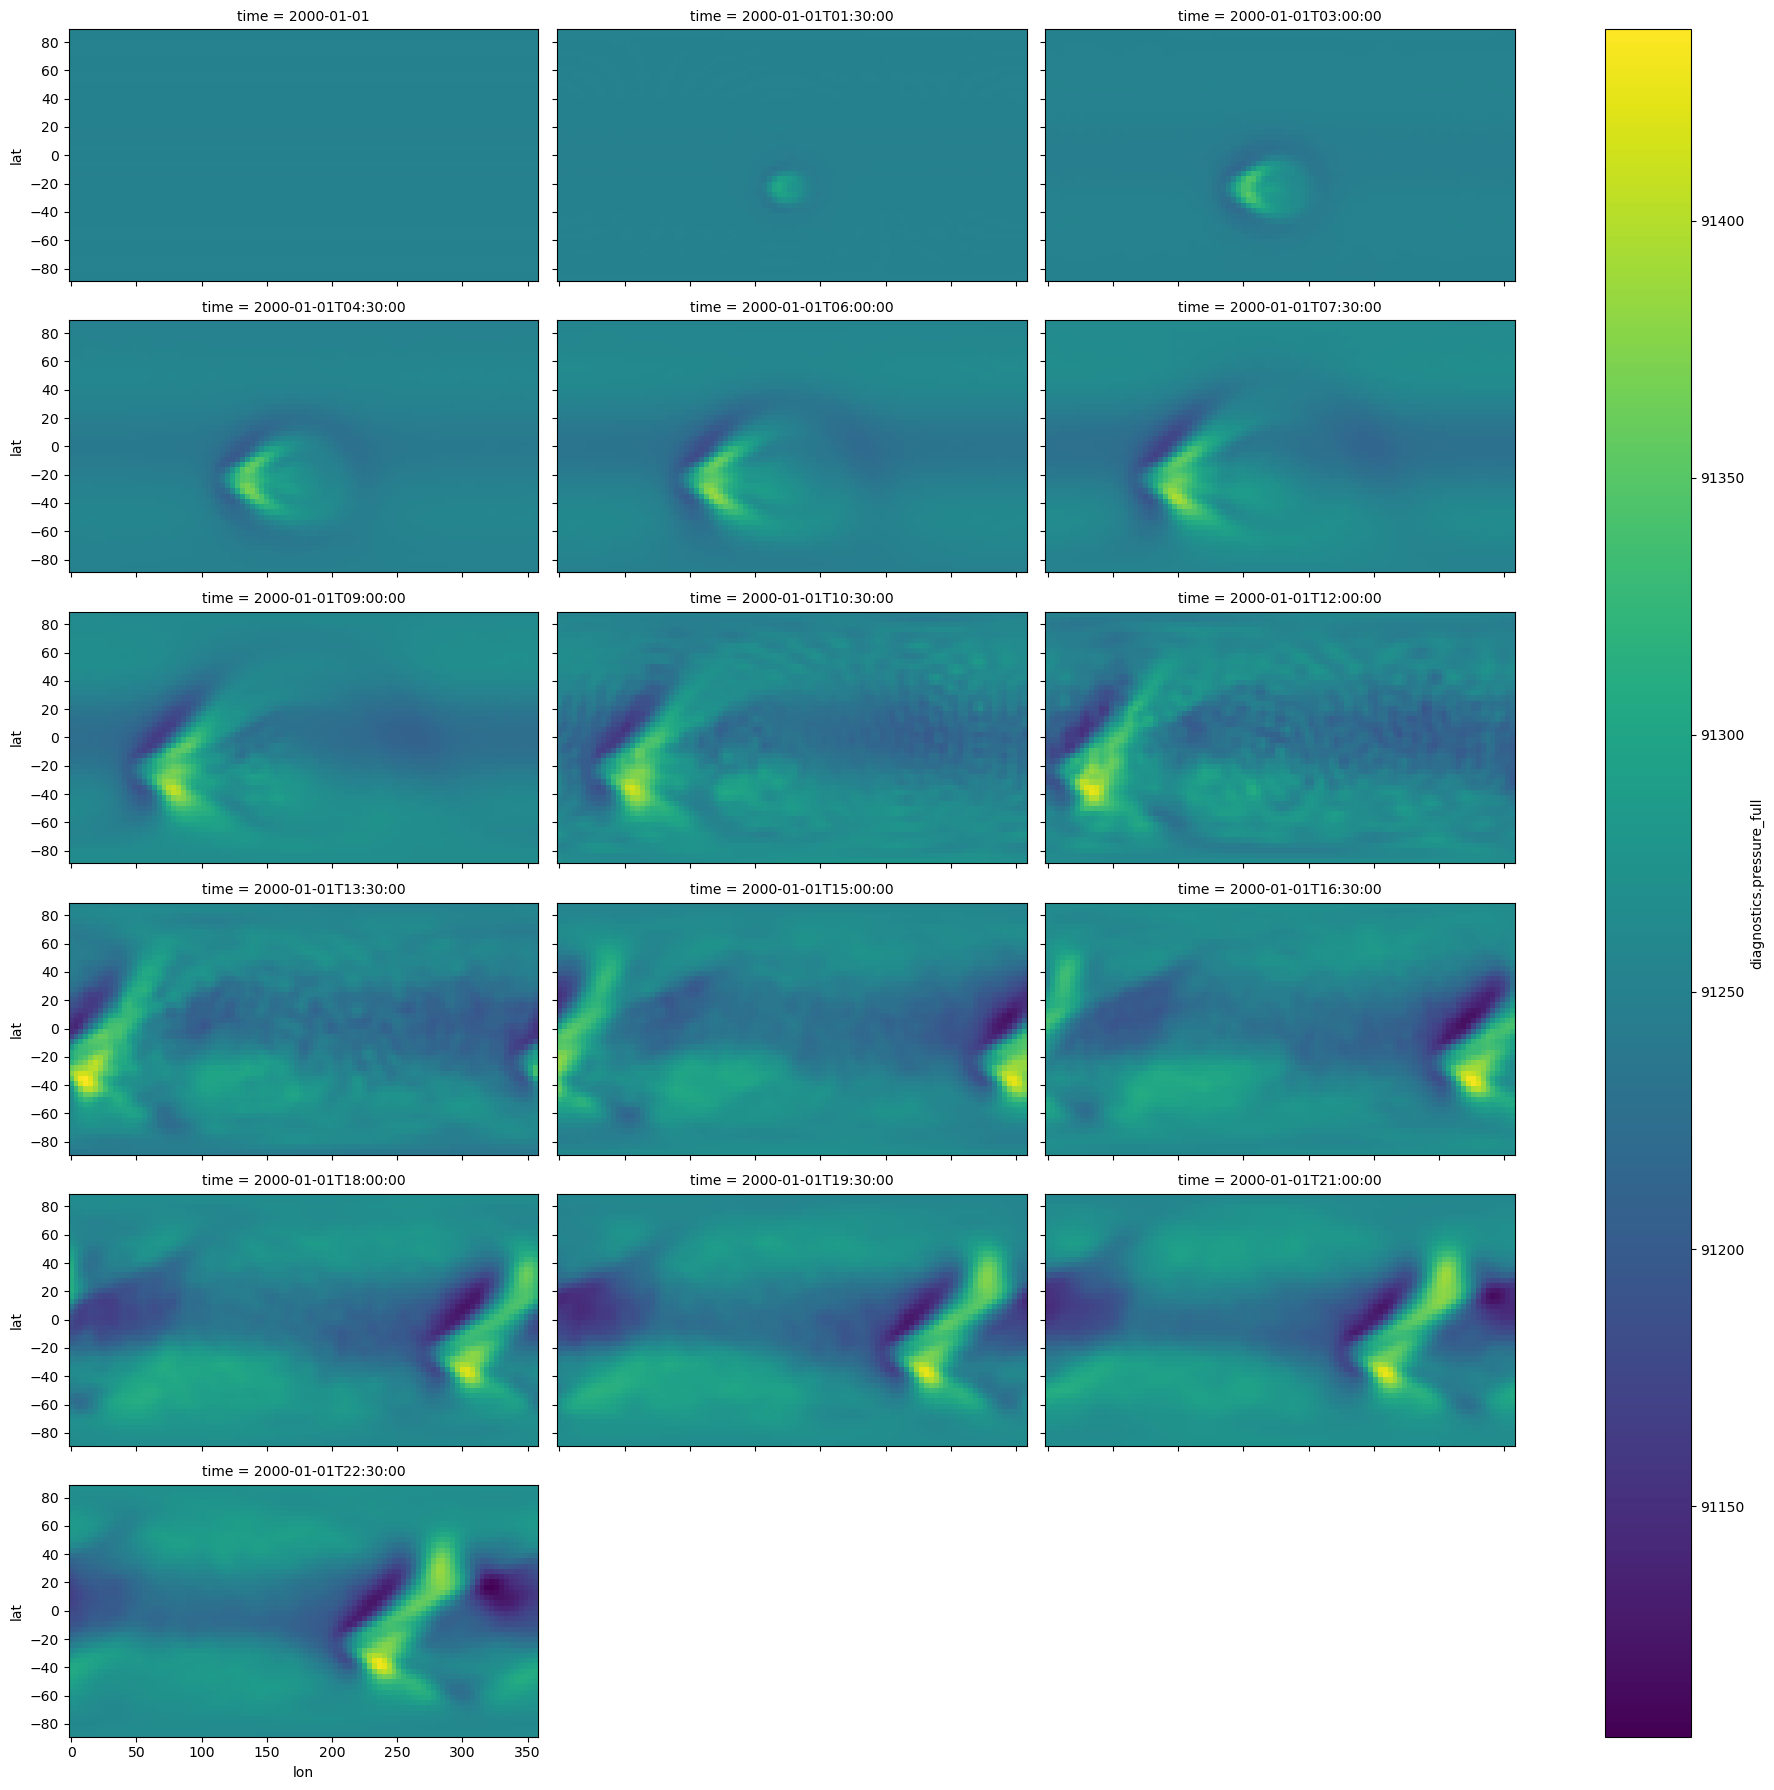

In [5]:
pred_ds['diagnostics.pressure_full'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
pred_ds['diagnostics.pressure_full'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

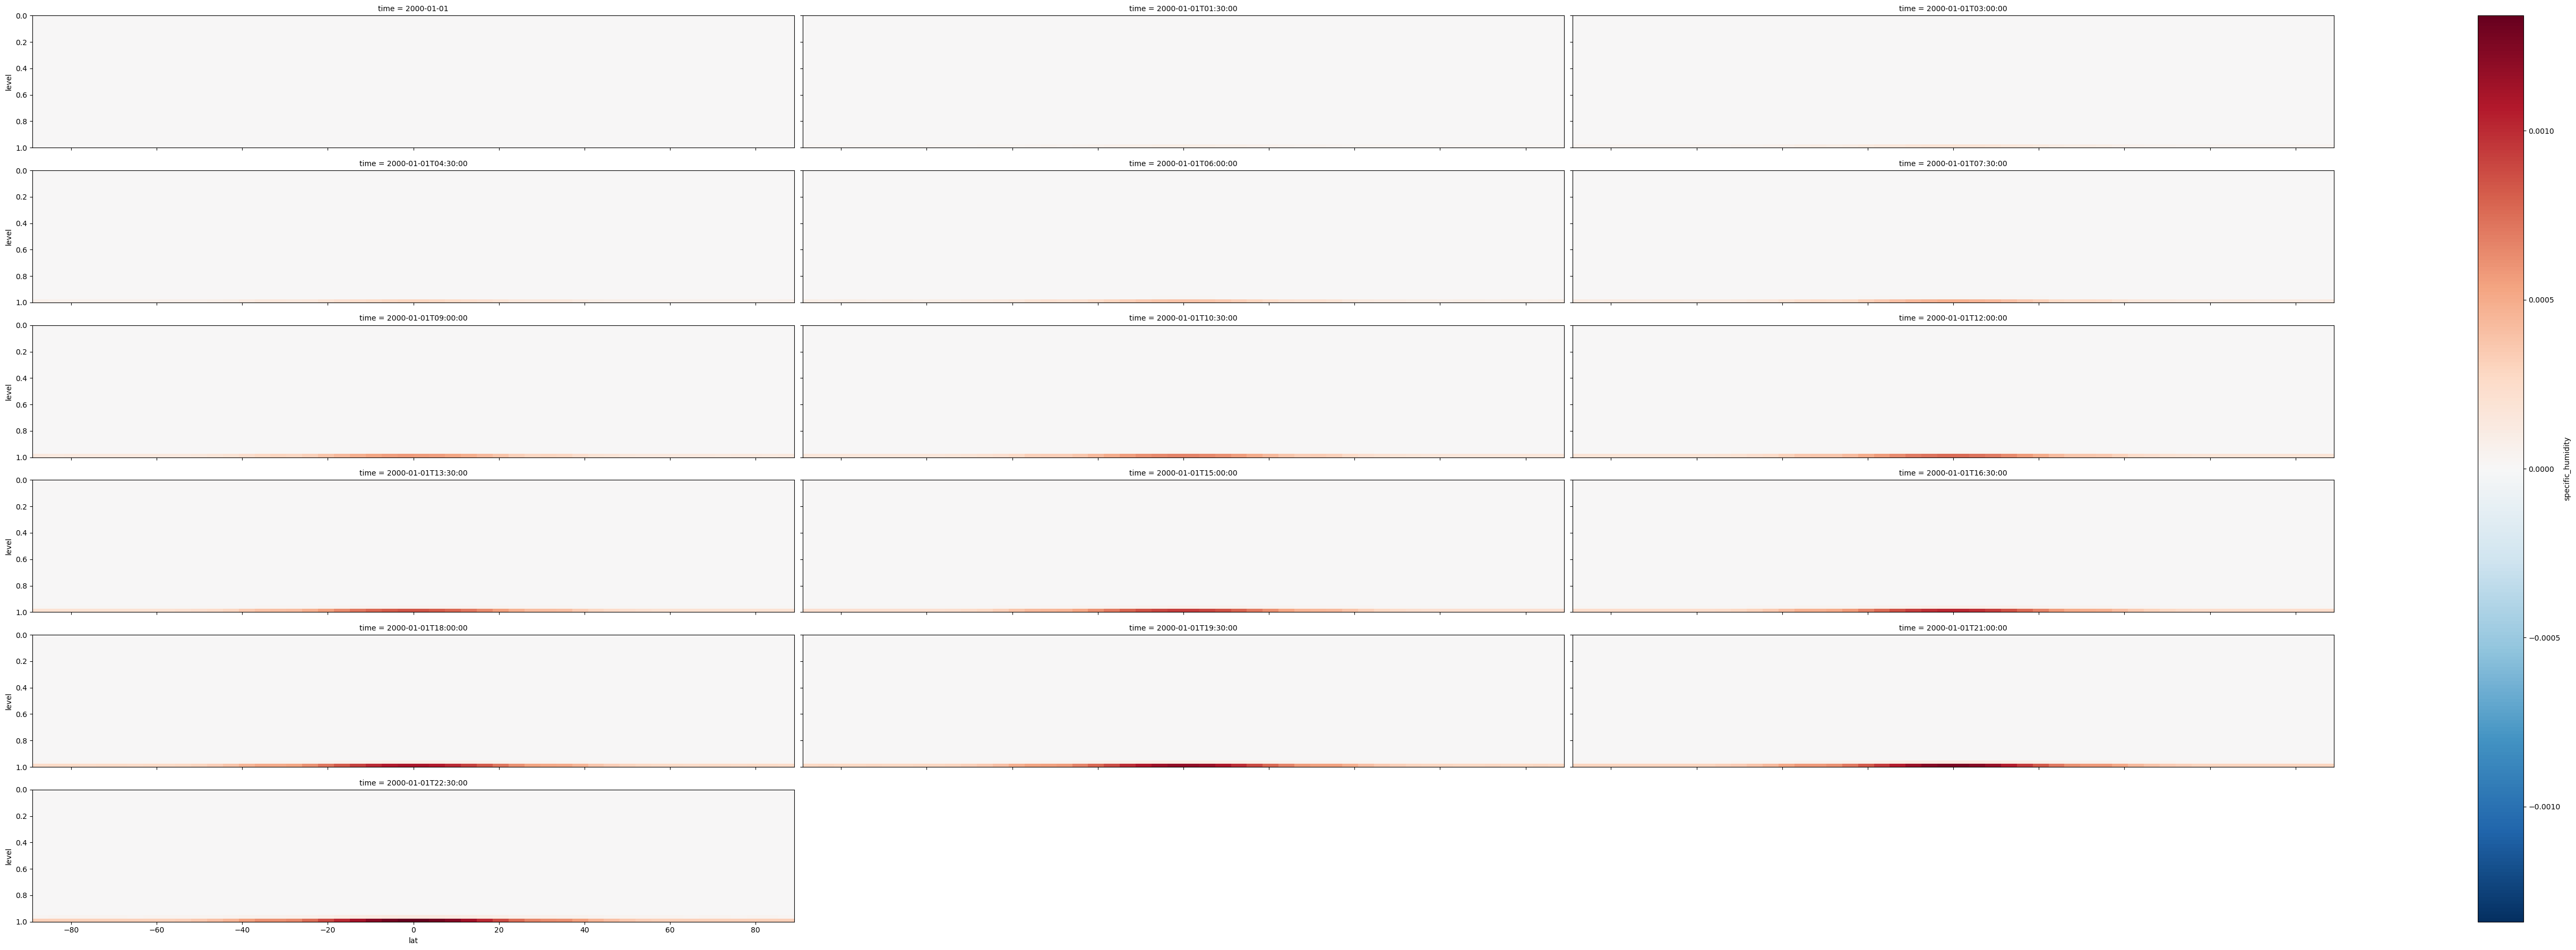

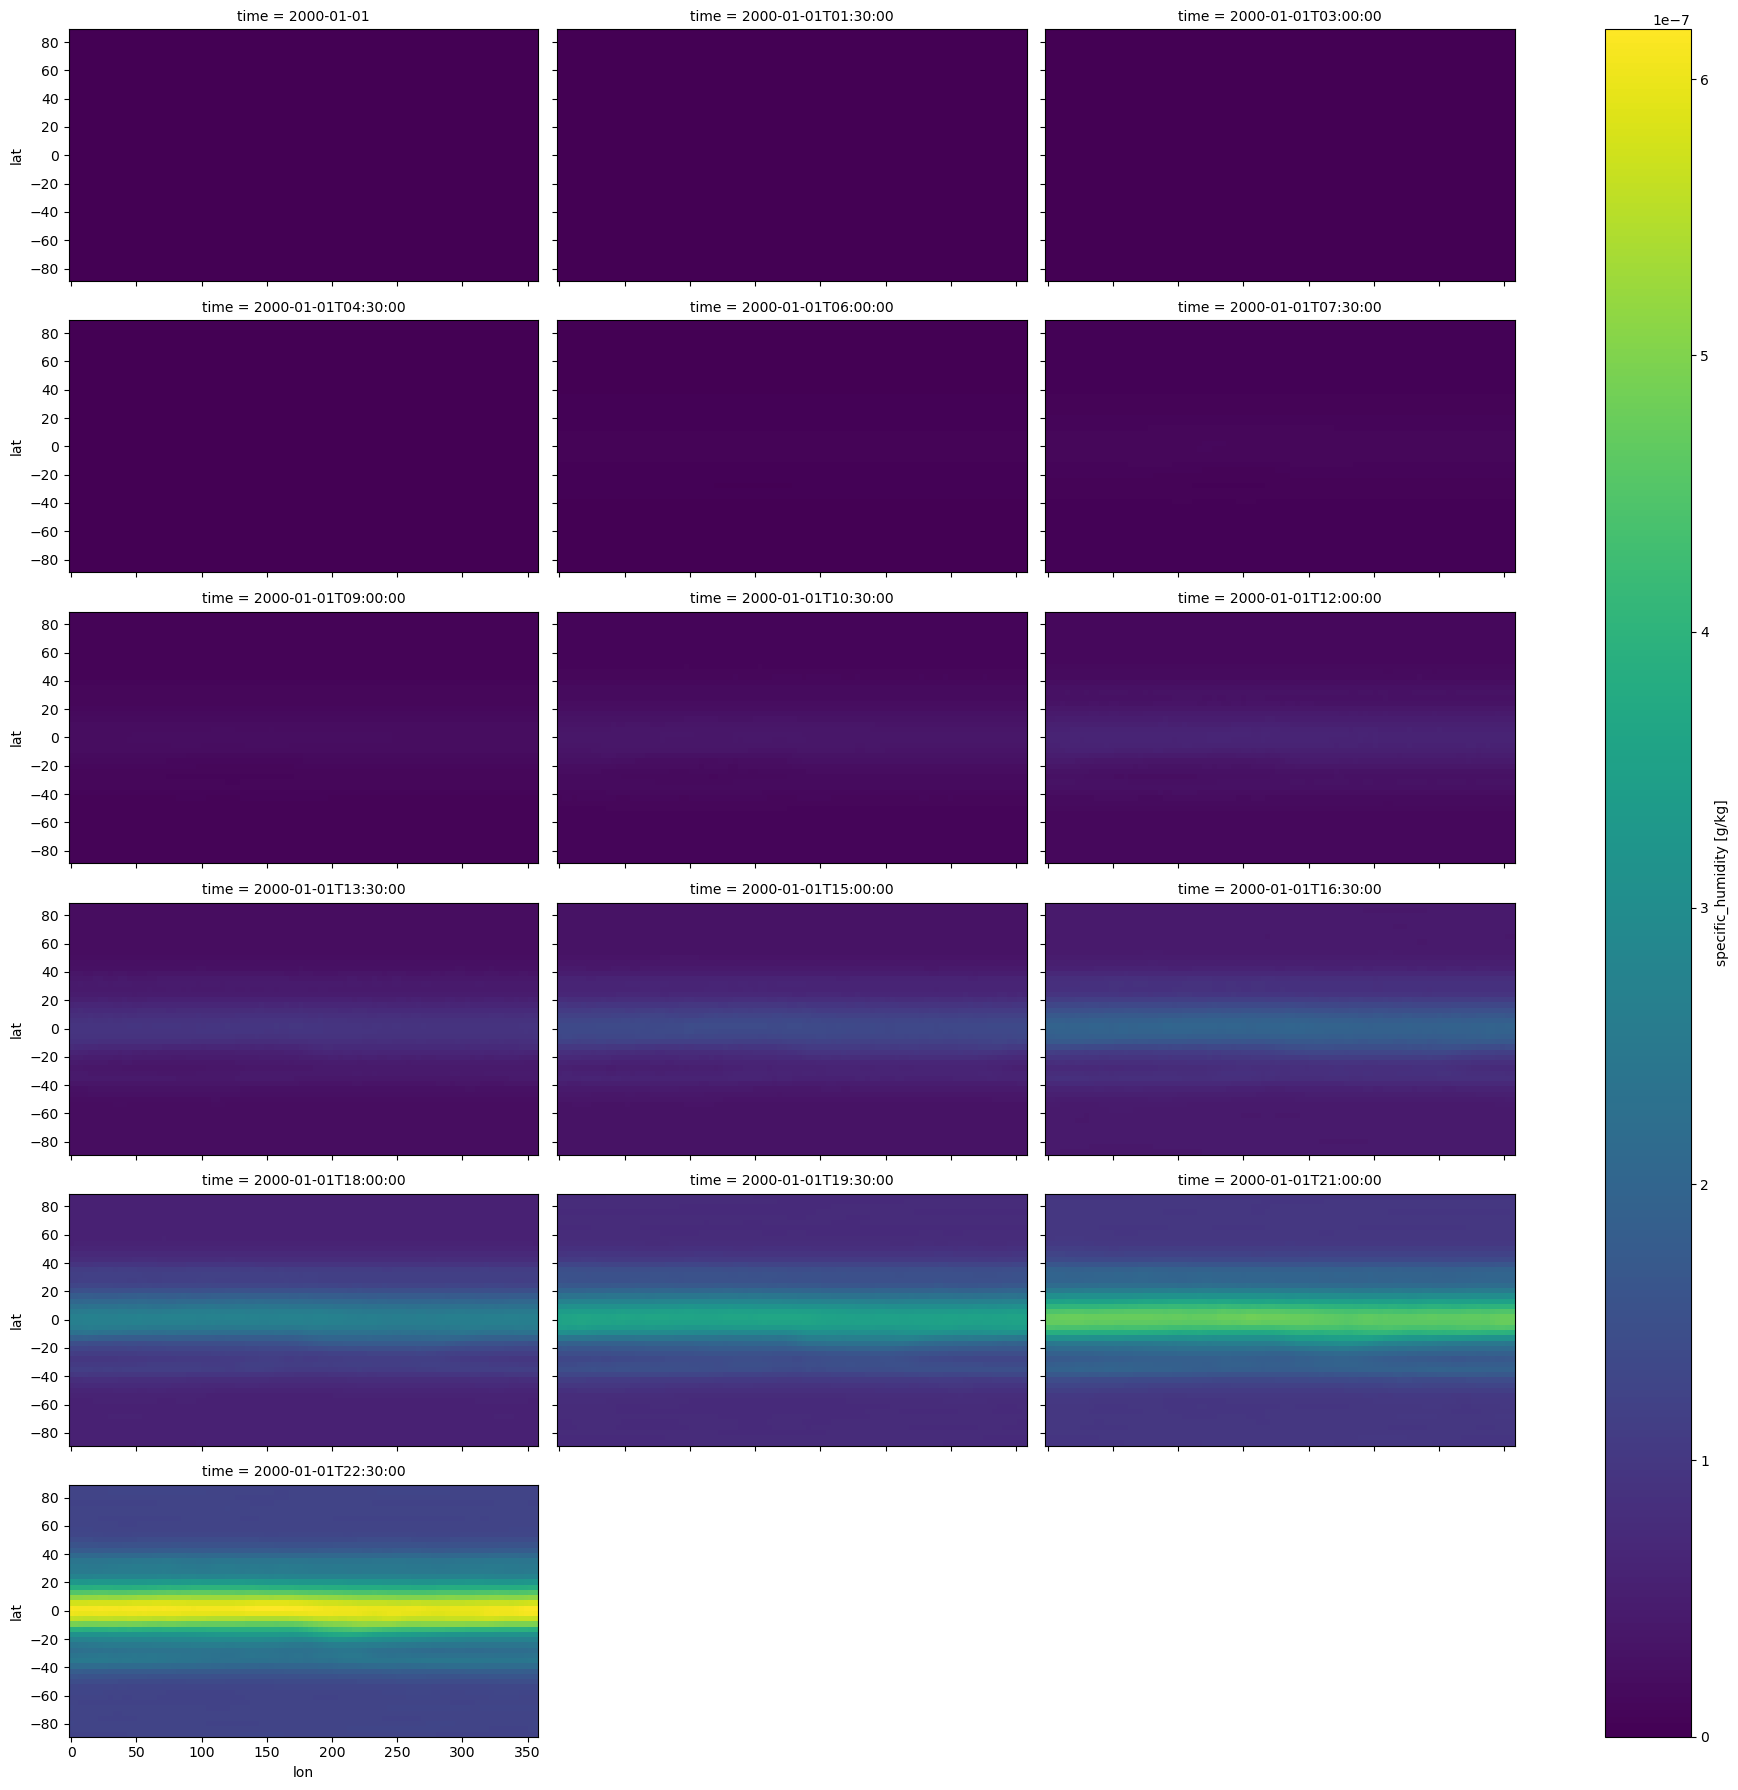

In [6]:
pred_ds['specific_humidity'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
pred_ds['specific_humidity'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

### Clouds!

In [7]:
pred_ds['shortwave_rad.cloudc'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
pred_ds['shortwave_rad.qcloud'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

KeyError: "No variable named 'shortwave_rad.cloudc'. Variables on the dataset include ['diagnostics.layer_thickness', 'clouds.precip_rain', 'specific_humidity', 'clouds.precip_snow', 'vertical_diffusion.monin_obukhov_length', ..., 'temperature', 'lon', 'lat', 'level', 'time']"

## Continue running

Continue a simulation from the previous state for an additional 30 days, saving every 5 days and outputting averages.


In [ ]:
predictions = model.resume(
    total_time=30,
    output_averages=True,
    forcing=realistic_forcing,
)

Sometimes, for example in a coupled run we want a pure JAX interface to enable compilation of a larger model. We can do this using the `run_from_state` method:

```python
model.run_from_state(
    initial_state=model._final_modal_state,
    total_time=30,
    output_averages=True,
    forcing=realistic_forcing,
)
```

## Note on speed and efficiency

Some preliminary tests show very good performance on a variety of devices but especially on GPUs and TPUs. For example, on a V100 GPU we see around 10x speedup compared to a CPU run. JCM also supports parallelization across multiple devices using JAX's `pmap` functionality, which can further enhance performance for large-scale simulations.

<center><img src="jcm_scaling.png" alt="JCM Performance" width="400"/></center>

## Model Gradients

We can compute gradients of model outputs with respect to model parameters using JAX's automatic differentiation. 

In [ ]:
import jax
import jax.numpy as jnp
import jax.tree_util as jtu
from jcm.physics.speedy.speedy_terms import speedy_physics
from jcm.physics.speedy.params import Parameters

# Key step - create a function that makes a model given parameters
def model_run_wrapper(params):
    model = Model(geometry=realistic_geometry, physics=speedy_physics(parameters=params))

    return model.run(save_interval=1, total_time=1, forcing=realistic_forcing, output_averages=True)

In [ ]:
# VJP is the vector-Jacobian product and calculates the gradient of outputs with respect to inputs

primal, vjp_fn = jax.vjp(model_run_wrapper, Parameters.default())

In [ ]:
def create_cotangent(primal):
    cotangent = jtu.tree_map(jnp.zeros_like, primal)
    cotangent.physics.shortwave_rad.ftop = jtu.tree_map(jnp.ones_like, cotangent.physics.shortwave_rad.ftop)
    return cotangent

grad, = vjp_fn(create_cotangent(primal))

In [ ]:
print(grad)

Parameters(convection=ConvectionParameters(psmin=0.0,
                                           trcnv=0.0,
                                           rhil=0.0,
                                           rhbl=0.0,
                                           entmax=0.0,
                                           smf=0.0),
           condensation=CondensationParameters(trlsc=0.0,
                                               rhlsc=0.0,
                                               drhlsc=0.0,
                                               rhblsc=0.0),
           shortwave_radiation=ShortwaveRadiationParameters(albcl=-0.034563131630420685,
                                                            albcls=-502230.5625,
                                                            absdry=1004539.0625,
                                                            absaer=297534.34375,
                                                            abswv1=159370.4375,
                               

We can also calculate the Jacobian-vector product (JVP) to get gradients of specific outputs with respect to a parameter

In [ ]:
# Define a tangent vector for JVP
params = Parameters.default()
tangent = Parameters.zeros()
tangent.mod_radcon.albsea = jnp.array(1.)

y, jvp_at_x = jax.jvp(model_run_wrapper, (params,), (tangent,))

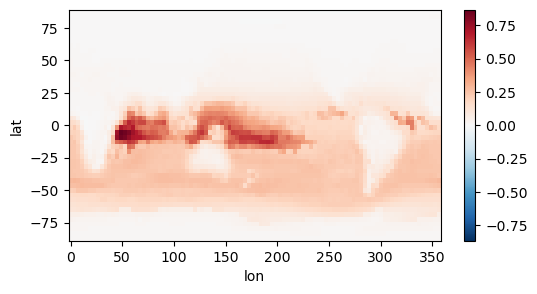

In [ ]:
import xarray as xr
xr.DataArray(jvp_at_x.physics.surface_flux.hfluxn[0, :, :, 0], dims=['lon', 'lat'],
                coords={'lat': pred_ds.lat, 'lon': pred_ds.lon}).plot(x='lon', y='lat', size=3, aspect=2)

## Advanced

Sometimes it can be useful to control the compilation or execution of the JAX code more directly. JAX has configuration functions to facilitate this.

In [ ]:
print("JAX device:", jax.devices())

# import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"  # for use on ARM Macs

jax.config.update('jax_disable_jit', False) # disable if necessary for debugging
jax.config.update("jax_debug_infs", True) # watch for model blowup
jax.config.update("jax_debug_nans", False) # some physics fields might be nan